In [1]:
from torchvision.datasets import MNIST
from torchvision import transforms as T

import numpy as np

from torch.utils.data import DataLoader, Subset

from torch import nn
from torch.nn import functional as F

import pytorch_lightning as pl
from datetime import datetime

import torchmetrics
import torch

from xaikd import attributors, bases
from xaikd.utils import metrics

from matplotlib import pyplot as plt 


import pandas as pd
import zennit

In [2]:
SEED = 1
NUM_WORKERS = 2
BATCH_SIZE = 64

data_mean = 0.1307
data_std = 0.3081

MAIN_TRANSFORM = T.Compose([
    T.ToTensor(),
    T.Normalize((data_mean,), (data_std,))
    ])

In [3]:
def get_loaders():
    data_class = MNIST
    
    train_ds = data_class(
        root="./datasets", train=True, transform=MAIN_TRANSFORM, download=True
    )

    val_ds = data_class(
        root="./datasets", train=False, transform=MAIN_TRANSFORM, download=True
    )

    return DataLoader(train_ds, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=True), \
        DataLoader(val_ds, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=False), \

train_loader, val_loader = get_loaders()

In [4]:
class MLP(nn.Module):
    def __init__(self, input_channels=1):
        super().__init__()
        
        nhidden = 128
        self.lin1 = nn.Linear(784, nhidden)
        self.act1 = nn.ReLU()
        
        self.dropout = nn.Dropout()
        
        self.lin2 = nn.Linear(nhidden, 10)
        
    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.dropout(self.act1(self.lin1(x)))
        x = self.lin2(x)

        return x


class ModelWrapper(pl.LightningModule):
    def __init__(self, model):
        super().__init__()

        self.model = model

        self.valid_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)

    def forward(self, x):
        embedding = self.model(x)
        return embedding

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        x, y = train_batch

        yh = self.model(x)

        loss = F.cross_entropy(yh, y)
        
#         if batch_idx % 200 == 0:
#             print(loss)

        return loss
    
    def validation_step(self, val_batch, batch_idx):
        x, y = val_batch

        logits = self.model(x)
        self.valid_acc.update(logits, y)

    def on_validation_epoch_end(self):
        acc = self.valid_acc.compute()
        print(f"acc={acc}")
        self.log('valid_acc_epoch', self.valid_acc.compute())
        self.valid_acc.reset()

        
def train(model, epochs=5, device="cpu"):

    pl.seed_everything(SEED)

    start_time = datetime.now()

    trainer = pl.Trainer(accelerator=device, max_epochs=epochs)

    
    trainer.fit(ModelWrapper(model), train_loader, val_loader)
    
    print("Time Took:", (datetime.now() - start_time) / 60, "mins")

In [5]:
# torch.manual_seed(SEED)

# model = MLP()

In [6]:
# train(model, epochs=20)

In [7]:
# torch.save(model.state_dict(), "../../artifacts/2023-07-s9/local/mlp-mnist.pth")

In [8]:
teacher_model = MLP()
teacher_model.load_state_dict(torch.load("../../artifacts/2023-07-s9/local/mlp-mnist.pth"))
teacher_model.eval()
metrics.accuracy(teacher_model, val_loader, num_classes=10, device="cpu")

0.9767000079154968

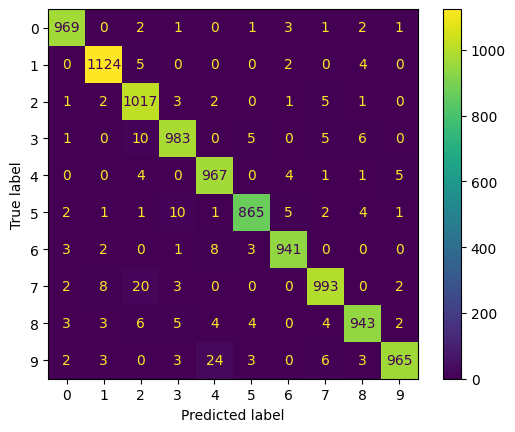

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
def confustion_mat():
    
    arr_y = []
    arr_yh = []
    for x, y in val_loader:
        logits = teacher_model(x)
        yh = torch.argmax(logits, dim=1)
        
        arr_y.extend(y.numpy().tolist())
        arr_yh.extend(yh.numpy().tolist())
    
    return ConfusionMatrixDisplay.from_predictions(arr_y, arr_yh)
    
confustion_mat()

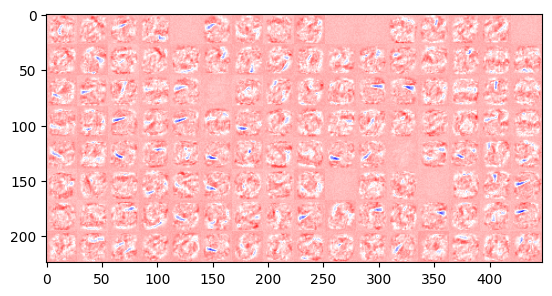

In [10]:
def viz_filter(weight):
    total = weight.shape[0]
    
    filters = weight.reshape((total, 28, 28))
    
    ncols = 16
    nrows = total / ncols 
    
#     plt.figure(figsize=(2*))
    plt.imshow(
        zennit.image.gridify(filters, shape=(8, 16)),
        cmap="bwr"
    )
    
viz_filter(teacher_model.lin1.weight.detach().cpu().numpy())

# Explaining

In [11]:
MAIN_TRANSFORM.transforms[1]

Normalize(mean=(0.1307,), std=(0.3081,))

tensor(22.1636, grad_fn=<MaxBackward1>)


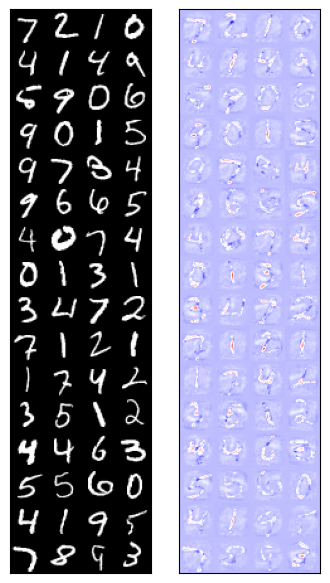

In [12]:
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

low, high = MAIN_TRANSFORM.transforms[1](torch.tensor([[[[[0.0]]] * 1], [[[[1.0]]] * 1]]))

composite = EpsilonGammaBox(low=low, high=high)


def explain():
    x, y = next(iter(val_loader))
    
    with Gradient(model=teacher_model, composite=composite) as attributor:
        logits, heatmaps = attributor.forward(x, lambda logits: F.one_hot(y, num_classes=10) * logits)
        print((logits * F.one_hot(y)).max())
    plt.figure(figsize=(4, 2*8))
    plt.subplot(1, 2, 1)
    plt.imshow(
        zennit.image.gridify(x.numpy(), shape=(16, 4)),
        cmap="gray"
    ) 
    plt.xticks([]); plt.yticks([])
    plt.subplot(1, 2, 2)
    plt.imshow(
        zennit.image.gridify(heatmaps.numpy(), shape=(16, 4)),
        cmap="bwr"
    )   
    plt.xticks([]); plt.yticks([])

        
explain()

In [13]:
from xaikd import utils

utils.interceptor.attach_hook_intercept_module

<function xaikd.utils.interceptor.attach_hook_intercept_module(module: torch.nn.modules.module.Module) -> Tuple[torch.nn.modules.module.Module, torch.utils.hooks.RemovableHandle]>

In [45]:
CONSIDERED_CLASSES = [4, 9]

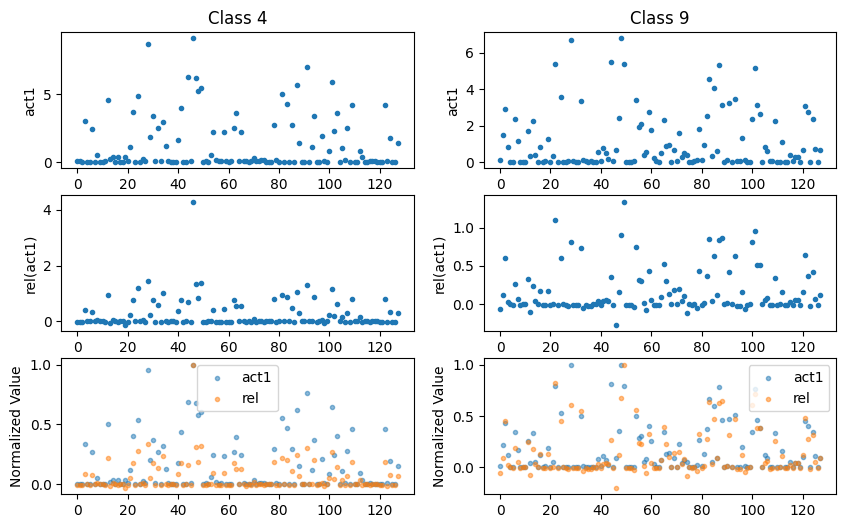

In [46]:
def viz_activation():
    ncols = len(CONSIDERED_CLASSES)
    
    nrows = 3
    plt.figure(figsize=(ncols * 5, 2*nrows))
    
    module = teacher_model.act1
    
    for ix, cix in enumerate(CONSIDERED_CLASSES):
        train_ds = MNIST(
            root="./datasets", train=True, transform=MAIN_TRANSFORM, download=True
        )
        
        subset = Subset(train_ds, indices=np.argwhere(train_ds.targets == cix).reshape(-1))
        
        arr_act = []
        arr_ctx = []
        for x, y in DataLoader(subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE):
            assert (y == cix).all()
#             with torch.no_grad():
            try:
                module, hook = utils.interceptor.attach_hook_intercept_module(module)
                with Gradient(model=teacher_model, composite=composite) as attributor:
                    _ = attributor.forward(x, lambda logits: F.one_hot(y, num_classes=10) * logits)
            
                act = utils.interceptor.get_output(module)
                rel = act.grad
                
#                 print("rel.max()", rel.max(), "rel.min()", rel.min())
                
                # todo: check this with Gregoire again!
                ctx = torch.where(act.abs() > 0, rel / act, 0)
            
                arr_act.append(act.detach())
                arr_ctx.append(ctx.detach())
                
            finally:
                hook.remove()
            
        arr_act = torch.vstack(arr_act).numpy()
        arr_ctx = torch.vstack(arr_ctx).numpy()

        mean = arr_act.mean(axis=0)
        
        mean_rel = (arr_act * arr_ctx).mean(axis=0)
        
        plt.subplot(nrows, ncols, ix+1)
        plt.title(f"Class {cix}")

        plt.scatter(np.arange(mean.shape[0]), mean, marker=".", label="act1")
        plt.ylabel("act1")
        plt.xlabel("Dimension")
        
        plt.subplot(nrows, ncols, ncols + ix+1)

        plt.scatter(np.arange(mean.shape[0]), mean_rel, marker=".", label="act1")
        plt.ylabel("rel(act1)")
        plt.xlabel("Dimension")
        
        
        plt.subplot(nrows, ncols, 2*ncols + ix+1)
        
        
        plt.scatter(np.arange(mean.shape[0]), mean / np.max(mean), marker=".", alpha=0.5, label="act1")
        plt.scatter(np.arange(mean.shape[0]), mean_rel / np.max(mean_rel), marker=".", alpha=0.5, label="rel")
        plt.ylabel("Normalized Value")
        plt.legend()

        
viz_activation()

# Build Basis

In [77]:
def build_basis():
    
    module = teacher_model.act1

    considered_classes = CONSIDERED_CLASSES
    
    logit_mod = attributors.LogOddEvidence(considered_classes)
#     logit_mod = attributors.OneClassEvidence(considered_classes)

    
    train_ds = MNIST(
        root="./datasets", train=True, transform=MAIN_TRANSFORM, download=True
    )
        
    subset = Subset(train_ds, indices=np.argwhere(np.isin(train_ds.targets.numpy(), considered_classes)).reshape(-1))
        
    arr_act = []
    arr_ctx = []
    for x, y in DataLoader(subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE):
        assert (np.isin(y, [considered_classes])).all()

        try:
            
            module, hook = utils.interceptor.attach_hook_intercept_module(module)
            with Gradient(model=teacher_model, composite=composite) as attributor:
                _ = attributor.forward(x, lambda logits: logit_mod(logits))

            act = utils.interceptor.get_output(module)
            rel = act.grad

            ctx = torch.where(act.abs() > 0, rel / act, 0)

            arr_act.append(act.detach())
            arr_ctx.append(ctx.detach())

        finally:
            hook.remove()
            
    arr_act = torch.vstack(arr_act).numpy()
    mean = np.zeros(arr_act.shape[1])
    arr_act = arr_act - mean
    
    arr_ctx = torch.vstack(arr_ctx).numpy()
    
    _, eigvecs = np.linalg.eigh(arr_act.T @ arr_act / arr_act.shape[0])
    
    Upca = np.copy(eigvecs[:, ::-1])
    
    torch.manual_seed(1)
    prca_abs = bases.PRCAAbs(alias="prca-abs", centering=False)
    
    prca_abs.fit(arr_act, arr_ctx, mean=None)
    
    Uprca = prca_abs.artifact["eigvecs"]
    
    return Upca, Uprca, mean

Upca, Uprca, act_mean = build_basis()

[mode=abs,beta=0.0,device=cpu]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:51<00:00,  2.46it/s]


In [78]:
def build_subclasses_loader():
    
    val_ds = MNIST(
        root="./datasets", train=False, transform=MAIN_TRANSFORM, download=True
    )
        
    subset = Subset(val_ds, indices=np.argwhere(np.isin(val_ds.targets.numpy(), CONSIDERED_CLASSES)).reshape(-1))
       
    return DataLoader(subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE)

val_subclasses_dl = build_subclasses_loader()

In [79]:
teacher_auroc, _ = metrics.auroc(teacher_model, val_subclasses_dl, classes=CONSIDERED_CLASSES, device="cpu", should_convert_auroc=True)
teacher_auroc

0.996569037437439

In [81]:
def construct_fh_hook_projection(U): 


    A = torch.from_numpy(U @ U.T).float()
    mean = torch.from_numpy(act_mean).float()
    def fh(mod, input, output):
        assert isinstance(output, torch.Tensor)

        return (output - mean ) @ A + mean

    return fh

def compute_auroc(U, verbose=False):
    layer = "act1"
    
    val_ds = MNIST(
        root="./datasets", train=False, transform=MAIN_TRANSFORM, download=True
    )
        
    subset = Subset(val_ds, indices=np.argwhere(np.isin(val_ds.targets.numpy(), CONSIDERED_CLASSES)).reshape(-1))
       
    dl = DataLoader(subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE)
    
    try:
        module = getattr(teacher_model, layer)
        
        hook = module.register_forward_hook(construct_fh_hook_projection(U))
        
        auroc, _ = metrics.auroc(teacher_model, dl, classes=CONSIDERED_CLASSES, device="cpu", should_convert_auroc=True)
        
        if verbose:
            print(f"auroc={auroc:.4f}")
    finally:
        hook.remove()
        
    return auroc

compute_auroc(Upca[:, :10])

0.9932284355163574

# Basis Quality

In [82]:
def estimate_auroc_bases():
    
    
    arr_rows = []
    for basis, U in [
        ("pca", Upca),
        ("prca", Uprca)
    ]:
        for k in range(1, 10+1):
            auroc = compute_auroc(U[:, :k])
            arr_rows.append(
                dict(
                    name=basis,
                    k=k,
                    auroc=auroc
                )
            )
    return pd.DataFrame(arr_rows)

df = estimate_auroc_bases()

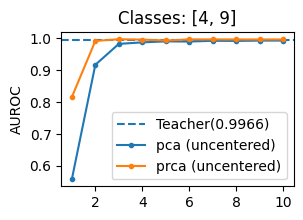

In [83]:
def viz():
    plt.figure(figsize=(3, 2))
    basis_names = df.name.unique()
    
    plt.title(f"Classes: {CONSIDERED_CLASSES}")
    plt.axhline(teacher_auroc, ls="--", label=f"Teacher({teacher_auroc:.4f})")

    for name in basis_names:
        _df = df[df.name == name]
        
        plt.plot(_df.k, _df.auroc, label=f"{name} (uncentered)", marker=".")
        
    plt.legend()
    plt.ylabel("AUROC")
        
viz()

In [53]:
class Approximator(nn.Module):
    def __init__(self, U, input_channels=1):
        super().__init__()
    
        k = U.shape[1]
        
        self.U = torch.from_numpy(U)
        
        self.lin1 = nn.Linear(784, k)
        
    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.lin1(x)
                
        return x


class ApproximatorModelWrapper(pl.LightningModule):
    def __init__(self, approx, teacher):
        super().__init__()

        self.approx = approx
        self.teacher = teacher


    def configure_optimizers(self):
        optimizer = torch.optim.SGD(self.approx.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        x, y = train_batch

                
        assert np.isin(y.numpy(), CONSIDERED_CLASSES).all()
        
        a = self.teacher.act1(self.teacher.lin1(x.flatten(start_dim=1)))
        
        au = a @ self.approx.U
        
        ah = self.approx(x)
        
        
        loss = (au-ah) ** 2
        loss = loss.sum(dim=1).mean()
        if batch_idx % 100 == 0:
            print(f"[batch_ix={batch_idx}] loss={loss.detach().numpy():.4f}")
        
        return loss
    

def train_approximator(approximator, teacher, epochs=20, device="cpu"):
    pl.seed_everything(SEED)

    train_ds = MNIST(
        root="./datasets", train=True, transform=MAIN_TRANSFORM, download=True
    )
        
    subset = Subset(train_ds, indices=np.argwhere(np.isin(train_ds.targets, CONSIDERED_CLASSES)).reshape(-1))

    dl = DataLoader(subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE, shuffle=True)
    
    
    start_time = datetime.now()

    trainer = pl.Trainer(accelerator=device, max_epochs=epochs)

    
    trainer.fit(ApproximatorModelWrapper(approximator, teacher), dl)
    
    print("Time Took:", (datetime.now() - start_time) / 60, "mins")

    return approximator

k = 2

approx_pca = Approximator(Upca[:, :k])

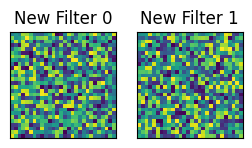

In [54]:
def viz_filter_approx(approx):
    weight = approx.lin1.weight.detach().numpy()
    
    ncols = weight.shape[0]
    
    nrows = 1
    plt.figure(figsize=(1.5*ncols, 1.5*nrows))
    
    for i in range(ncols):
        plt.subplot(1, ncols, i+1)
        plt.title(f"New Filter {i}")
        plt.imshow(weight[i, ].reshape((28, 28)))
        plt.xticks([]); plt.yticks([])
        
viz_filter_approx(approx_pca)

In [55]:
approx_pca = train_approximator(approx_pca, teacher=teacher_model)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name    | Type         | Params
-----------------------------------------
0 | approx  | Approximator | 1.6 K 
1 | teacher | MLP          | 101 K 
-----------------------------------------
103 K     Trainable params
0         Non-trainable params
103 K     Total params
0.413     Total estimated model params size (MB)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

[batch_ix=0] loss=725.0333
[batch_ix=100] loss=17.3385
[batch_ix=0] loss=12.6861
[batch_ix=100] loss=9.1272
[batch_ix=0] loss=10.2750
[batch_ix=100] loss=7.2177
[batch_ix=0] loss=9.5926
[batch_ix=100] loss=7.8476
[batch_ix=0] loss=10.5020
[batch_ix=100] loss=10.1112
[batch_ix=0] loss=7.9248
[batch_ix=100] loss=8.8742
[batch_ix=0] loss=10.1605
[batch_ix=100] loss=7.7024
[batch_ix=0] loss=8.0496
[batch_ix=100] loss=8.2820
[batch_ix=0] loss=7.2382
[batch_ix=100] loss=6.9336
[batch_ix=0] loss=7.8876
[batch_ix=100] loss=7.1269
[batch_ix=0] loss=7.1646
[batch_ix=100] loss=7.9423
[batch_ix=0] loss=8.9379
[batch_ix=100] loss=5.6824
[batch_ix=0] loss=6.1718
[batch_ix=100] loss=7.6128
[batch_ix=0] loss=8.1345
[batch_ix=100] loss=6.9008
[batch_ix=0] loss=7.2230
[batch_ix=100] loss=6.4785
[batch_ix=0] loss=7.7471
[batch_ix=100] loss=5.3773
[batch_ix=0] loss=6.4994
[batch_ix=100] loss=11.0771
[batch_ix=0] loss=7.7509
[batch_ix=100] loss=6.7859
[batch_ix=0] loss=6.9572
[batch_ix=100] loss=8.0852
[ba

`Trainer.fit` stopped: `max_epochs=20` reached.


Time Took: 0:00:00.473393 mins


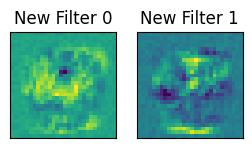

In [56]:
viz_filter_approx(approx_pca)

In [57]:
approx_prca = Approximator(Uprca[:, :k])

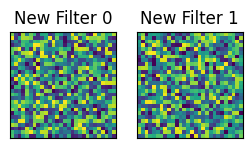

In [58]:
viz_filter_approx(approx_prca)

In [59]:
approx_prca = train_approximator(approx_prca, teacher=teacher_model)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name    | Type         | Params
-----------------------------------------
0 | approx  | Approximator | 1.6 K 
1 | teacher | MLP          | 101 K 
-----------------------------------------
103 K     Trainable params
0         Non-trainable params
103 K     Total params
0.413     Total estimated model params size (MB)


Training: 0it [00:00, ?it/s]

[batch_ix=0] loss=646.4113
[batch_ix=100] loss=16.4837
[batch_ix=0] loss=11.7830
[batch_ix=100] loss=9.1953
[batch_ix=0] loss=10.9183
[batch_ix=100] loss=8.6936
[batch_ix=0] loss=9.1215
[batch_ix=100] loss=8.1505
[batch_ix=0] loss=9.6512
[batch_ix=100] loss=9.5783
[batch_ix=0] loss=8.0171
[batch_ix=100] loss=8.6925
[batch_ix=0] loss=9.6331
[batch_ix=100] loss=7.3785
[batch_ix=0] loss=5.6301
[batch_ix=100] loss=7.6222
[batch_ix=0] loss=7.3562
[batch_ix=100] loss=7.0062
[batch_ix=0] loss=7.8329
[batch_ix=100] loss=6.5701
[batch_ix=0] loss=7.6683
[batch_ix=100] loss=7.7958
[batch_ix=0] loss=7.6463
[batch_ix=100] loss=6.8836
[batch_ix=0] loss=6.1385
[batch_ix=100] loss=8.6832
[batch_ix=0] loss=7.4491
[batch_ix=100] loss=7.2548
[batch_ix=0] loss=6.0635
[batch_ix=100] loss=5.9666
[batch_ix=0] loss=8.1128
[batch_ix=100] loss=6.1460
[batch_ix=0] loss=6.6524
[batch_ix=100] loss=9.8837
[batch_ix=0] loss=6.8693
[batch_ix=100] loss=6.0412
[batch_ix=0] loss=6.8024
[batch_ix=100] loss=8.2111
[batch_

`Trainer.fit` stopped: `max_epochs=20` reached.


Time Took: 0:00:00.461141 mins


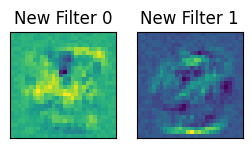

In [60]:
viz_filter_approx(approx_prca)

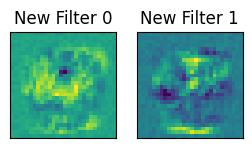

In [61]:
viz_filter_approx(approx_pca)

In [66]:
class CombinedModule(nn.Module):
    def __init__(self, approximator, teacher=teacher_model, input_channels=1):
        super().__init__()
        
        self.approximator = approximator
        self.teacher = teacher
        
        
        
    def forward(self, x):
        x = x.flatten(start_dim=1)
        a = self.approximator(x)
        
        au = a @ self.approximator.U.T
        
        x = self.teacher.lin2(au)

        return x

CombinedModule(approx_pca)

CombinedModule(
  (approximator): Approximator(
    (lin1): Linear(in_features=784, out_features=2, bias=True)
  )
  (teacher): MLP(
    (lin1): Linear(in_features=784, out_features=128, bias=True)
    (act1): ReLU()
    (dropout): Dropout(p=0.5, inplace=False)
    (lin2): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [67]:
metrics.auroc(CombinedModule(approx_pca), val_subclasses_dl, classes=CONSIDERED_CLASSES, device="cpu", should_convert_auroc=True)[0]

0.9310361742973328

In [68]:
metrics.auroc(CombinedModule(approx_prca), val_subclasses_dl, classes=CONSIDERED_CLASSES, device="cpu", should_convert_auroc=True)[0]

0.9901618361473083

In [65]:
raise

RuntimeError: No active exception to reraise

# Comparison to Ridge Regression (WIP)

In [ ]:
def get_selected_classes_X_and_Y(teacher, train=True):
    ds = MNIST(
        root="./datasets", train=train, transform=MAIN_TRANSFORM, download=True
    )
        
    subset = Subset(ds, indices=np.argwhere(np.isin(ds.targets, CONSIDERED_CLASSES)).reshape(-1))

    dl = DataLoader(subset, num_workers=NUM_WORKERS, batch_size=BATCH_SIZE)
    
    arr_x = []
    arr_y = []
    
    
    with torch.no_grad():
        for i, (x, _) in enumerate(dl):
            x = x.flatten(start_dim=1)
            a = teacher.act1(teacher.lin1(x))
            
            arr_x.append(x)
            arr_y.append(a)
        
    X = torch.vstack(arr_x)
    y = torch.vstack(arr_y)

    return X, y

selected_classes_X, selected_classes_y = get_selected_classes_X_and_Y(teacher_model, train=True)

In [ ]:
selected_classes_val_X, _ = get_selected_classes_X_and_Y(teacher_model, train=False)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge

@torch.no_grad()
def ols_fit(U, X_train, X_val, alpha=0.1, show_filter=False):

    k = U.shape[1]
    
    np.random.seed(1)
        
    
    def f(x):
        return teacher_model.act1(teacher_model.lin1(x.float())) @ U
    
    
    
    X = X_train
    
    Y = f(X)
    
    y = Y[:, 0]
    
    
    def prepend_col(X):
        return torch.hstack([X, torch.ones(X.shape[0]).reshape(-1, 1)])

    
    wh = torch.linalg.inv(
        prepend_col(X).T @ prepend_col(X) + alpha*torch.eye(X.shape[1]+1).float()
    ) @ prepend_col(X).T @ y
    
#     plt.imshow(wh.reshape((28, 28)))

    
    train_err = ((prepend_col(X_train)@wh - y)**2).mean()
    val_err = ((prepend_col(X_val)@wh - f(X_val))**2).mean()
    
    print(f"alpha={alpha}: {train_err, val_err}")
    
    if show_filter:
        plt.imshow(wh[:784].reshape((28, 28)))



    return train_err, val_err
     
approx_ols_pca = ols_fit(Upca[:, :1], selected_classes_X, selected_classes_val_X, alpha=10000, show_filter=True)

In [ ]:
approx_ols_pca = ols_fit(Uprca[:, :1], selected_classes_X, selected_classes_val_X, alpha=10000, show_filter=True)

In [ ]:
def viz_pen_path(U, arr_alphas):
    
    stats = []
    
    for alpha in arr_alphas:
        train_err, val_err = ols_fit(
            U, selected_classes_X, selected_classes_val_X, alpha=alpha,
            show_filter=False
        )
        
        stats.append((train_err, val_err))
        
    stats = np.array(stats)
    
    plt.plot(stats[:, 0], label="training")
    plt.plot(stats[:, 1], label="val")

    plt.legend()
    
    print(stats.shape)
viz_pen_path(Upca[:, :1], [1e-2, 1e-1, 1e-0, 1e1, 1e2, 1e3, 1e4, 1e10, 1e20])

In [ ]:
viz_pen_path(Uprca[:, :1], [1e-2, 1e-1, 1e-0, 1e1, 1e2, 1e3, 1e4, 1e10, 1e20])

In [ ]:
approx_ols_pca = ols_fit(Uprca[:, :1], selected_classes_X, selected_classes_val_X, alpha=1000)

In [ ]:
# approx_prca = train_approximator(Approximator(Uprca[:, :k]), teacher=teacher_model)

In [ ]:
# viz_filter_approx(approx_prca)

In [ ]:
approx_ols_prca = ols_fit(model, Uprca[:, :k])

In [ ]:
class CombinedModule(nn.Module):
    def __init__(self, approximator, teacher=model, input_channels=1):
        super().__init__()
        
        self.approximator = approximator
        self.teacher = teacher
        
        
        
    def forward(self, x):
        x = x.flatten(start_dim=1)
        a = self.approximator(x)
        
        au = a @ self.approximator.U.T
        
        x = self.teacher.lin2(au)

        return x

CombinedModule(approx_pca)

In [ ]:
metrics.auroc(CombinedModule(approx_pca), val_subclasses_dl, classes=CONSIDERED_CLASSES, device="cpu", should_convert_auroc=True)[0]

In [ ]:
metrics.auroc(CombinedModule(approx_ols_pca), val_subclasses_dl, classes=CONSIDERED_CLASSES, device="cpu", should_convert_auroc=True)[0]

In [ ]:
metrics.auroc(CombinedModule(approx_prca), val_subclasses_dl, classes=CONSIDERED_CLASSES, device="cpu", should_convert_auroc=True)[0]

In [ ]:
metrics.auroc(CombinedModule(approx_ols_prca), val_subclasses_dl, classes=CONSIDERED_CLASSES, device="cpu", should_convert_auroc=True)[0]

TODO
- Training models (standard training)
- visualize features (relevance per class)
- extract activations running PCA finetune ...

In [ ]:
print(f"Finished successfully {datetime.now()}")